<a href="https://colab.research.google.com/github/estebantarrifa07/CSV/blob/main/IA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 1: Diagnóstico y planificación del dataset

Objetivo:
Evaluar si un dataset está listo para IA e identificar problemas y soluciones.

Este dataset representa clientes de una empresa.

Variable objetivo:
Churn → indica si el cliente abandona el servicio.

# 📘 Limpieza y Preparación de Datos para IA

## 🎯 Objetivo
Aprender a detectar problemas en un dataset y prepararlo para modelos de IA.

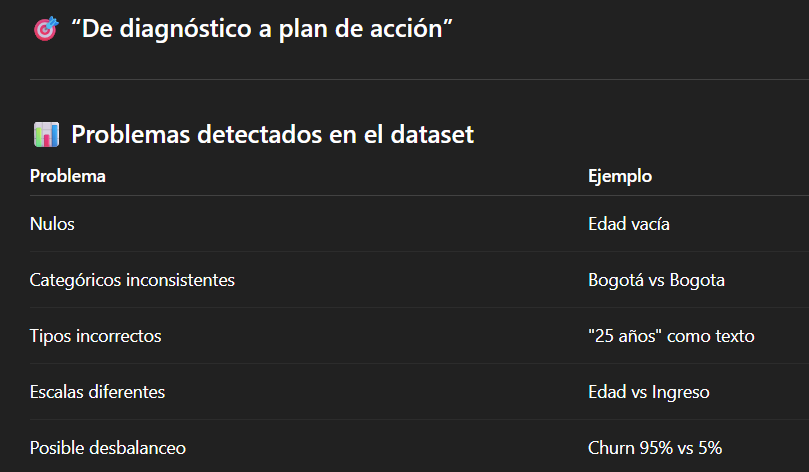

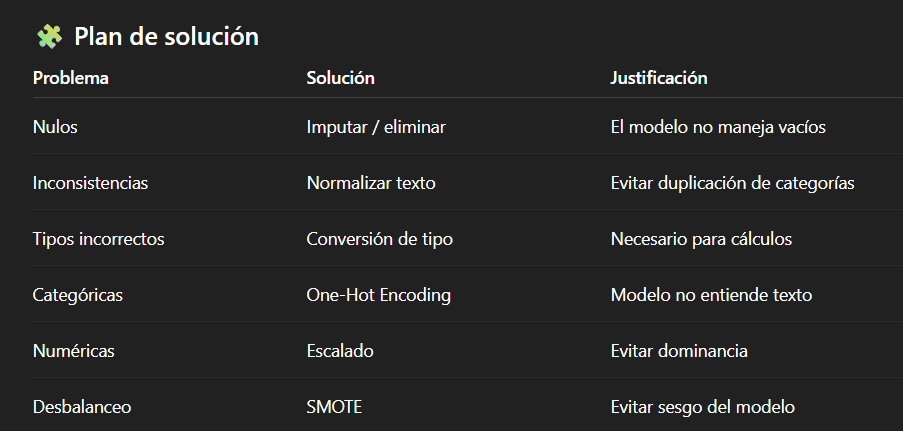

## 📊 1. Librerías

In [ ]:
import pandas as pd
import numpy as np

## 📊 2. Dataset

In [ ]:
data = {
    "Edad": [25, 32, 40, np.nan, 29],
    "Ingreso": [1200, 2500, None, 2800, 3000],
    "Ciudad": ["Bogotá", "Bogota", "Cali", "Medellín", "Cali"],
    "Churn": ["No", "No", "Sí", "No", "Sí"]
}

df = pd.DataFrame(data)
df

,Edad,Ingreso,Ciudad,Churn
0,25.0,1200.0,Bogotá,No
1,32.0,2500.0,Bogota,No
2,40.0,NaN,Cali,Sí
3,NaN,2800.0,Medellín,No
4,29.0,3000.0,Cali,Sí


## 🔍 3. Exploración

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Edad     4 non-null      float64
 1   Ingreso  4 non-null      float64
 2   Ciudad   5 non-null      object 
 3   Churn    5 non-null      object 
dtypes: float64(2), object(2)
memory usage: 292.0+ bytes


In [ ]:
df.describe()

,Edad,Ingreso
count,4.000000,4.000000
mean,31.500000,2375.000000
std,6.350853,809.835374
min,25.000000,1200.000000
25%,28.000000,2175.000000
50%,30.500000,2650.000000
75%,34.000000,2850.000000
max,40.000000,3000.000000


## 🚨 4. Nulos

In [ ]:
df.isnull().sum()

,0
Edad,1
Ingreso,1
Ciudad,0
Churn,0


In [ ]:
df["Edad"] = df["Edad"].fillna(df["Edad"].mean())
df["Ingreso"] = df["Ingreso"].fillna(df["Ingreso"].mean())
df

,Edad,Ingreso,Ciudad,Churn
0,25.0,1200.0,Bogotá,No
1,32.0,2500.0,Bogota,No
2,40.0,2375.0,Cali,Sí
3,31.5,2800.0,Medellín,No
4,29.0,3000.0,Cali,Sí


## 🚨 5. Categóricos inconsistentes

In [ ]:
df['Ciudad'].unique()

array(['Bogotá', 'Bogota', 'Cali', 'Medellín'], dtype=object)

In [ ]:
df["Ciudad"] = df["Ciudad"].str.lower().str.strip()
df["Ciudad"] = df["Ciudad"].replace({"bogota": "bogotá"})
df

,Edad,Ingreso,Ciudad,Churn
0,25.0,1200.0,bogotá,No
1,32.0,2500.0,bogotá,No
2,40.0,2375.0,cali,Sí
3,31.5,2800.0,medellín,No
4,29.0,3000.0,cali,Sí


## 🚨 6. Tipos

In [ ]:
df.dtypes

,0
Edad,float64
Ingreso,float64
Ciudad,object
Churn,object


In [ ]:
df["Edad"] = pd.to_numeric(df["Edad"])
df["Ingreso"] = pd.to_numeric(df["Ingreso"])
df

,Edad,Ingreso,Ciudad,Churn
0,25.0,1200.0,bogotá,No
1,32.0,2500.0,bogotá,No
2,40.0,2375.0,cali,Sí
3,31.5,2800.0,medellín,No
4,29.0,3000.0,cali,Sí


## 🚨 7. Escalado

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[["Edad", "Ingreso"]] = scaler.fit_transform(df[["Edad", "Ingreso"]])
df

,Edad,Ingreso,Ciudad,Churn
0,0.000000,0.000000,bogotá,No
1,0.466667,0.722222,bogotá,No
2,1.000000,0.652778,cali,Sí
3,0.433333,0.888889,medellín,No
4,0.266667,1.000000,cali,Sí


## 🚨 8. Desbalanceo

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,3
Sí,2


In [ ]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,60.0
Sí,40.0


## 🎯 Conteo + %

In [ ]:
conteo = df["Churn"].value_counts()
porcentaje = df["Churn"].value_counts(normalize=True) * 100

df_churn = pd.DataFrame({
    "Conteo": conteo,
    "Porcentaje (%)": porcentaje.round(2)
})

df_churn

,Conteo,Porcentaje (%)
Churn,,
No,3,60.0
Sí,2,40.0


## 📈 Visualización

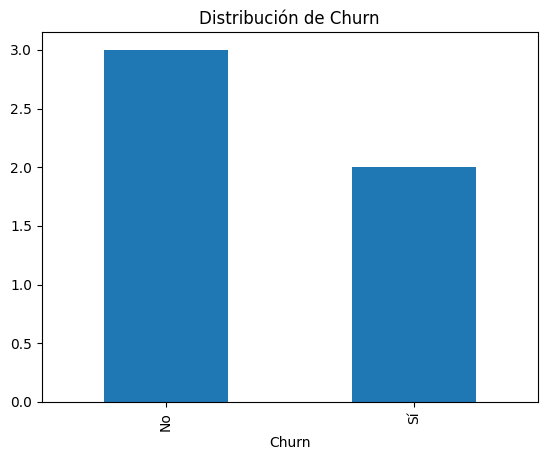

In [ ]:
import matplotlib.pyplot as plt

df_churn["Conteo"].plot(kind="bar")
plt.title("Distribución de Churn")
plt.show()

## ✅ Dataset final

In [ ]:
df

,Edad,Ingreso,Ciudad,Churn
0,0.000000,0.000000,bogotá,No
1,0.466667,0.722222,bogotá,No
2,1.000000,0.652778,cali,Sí
3,0.433333,0.888889,medellín,No
4,0.266667,1.000000,cali,Sí


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,3
Sí,2


In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,60.0
Sí,40.0
